<a href="https://colab.research.google.com/github/yeshaa23/ZARA-AppsReview-SentimentAnalysis/blob/main/Week2_Scrapping_Apps_Review_ZARA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Scrapping Google Apps Review - ZARA
Week 2 / Tugas1A-PBA-Genap-2026

#Installing dan Importing Library

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!pip install google-play-scraper
!pip install langdetect
!pip install textblob
!pip install nltk
!pip install seaborn

In [3]:
from google_play_scraper import app, reviews_all, Sort
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
import os

from langdetect import detect, LangDetectException
from textblob import TextBlob
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from collections import Counter

In [4]:
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

#Scraping Review App ZARA

In [5]:
#cek info app
zara_app = app(
    'com.inditex.zara',
    lang='en',
    country='us'
)

print("Nama Aplikasi   :", zara_app['title'])
print("Developer       :", zara_app['developer'])
print("Rating Aplikasi :", zara_app['score'])
print("Jumlah Review   :", zara_app['reviews'])

Nama Aplikasi   : Zara
Developer       : Inditex
Rating Aplikasi : 4.8117285
Jumlah Review   : 2811


In [6]:
#scraping review
zara_reviews = reviews_all(
    'com.inditex.zara',
    sleep_milliseconds=0,
    lang='en',
    country='us',
    sort=Sort.NEWEST
)

In [7]:
#ubah hasil scraping ke dataframe
df_zara = pd.DataFrame(np.array(zara_reviews), columns=['content'])
df_zara = df_zara.join(pd.DataFrame(df_zara.pop('content').tolist()))
df_zara.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,04d6b3d5-2fbf-4b12-9ff2-0a843f5f7c08,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,everytime I try to use it the app starts to up...,1,0,18.0.2,2026-03-30 05:33:51,None,None,18.0.2
1,5bd59236-9dff-495f-8662-f8442a01e127,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,smooth online purchase,5,0,18.4.0,2026-03-30 05:00:24,None,None,18.4.0
2,efe49412-03ce-4c15-b494-560128c4656f,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,Easy app to use,5,0,None,2026-03-29 21:28:12,None,None,None
3,1511edcc-c18e-41ea-9c9c-4efcdb932573,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,"great service, thanks",5,0,17.9.4,2026-03-29 10:04:34,None,None,17.9.4
4,60f112b0-a046-447f-b301-c103a15df5b0,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,website a nightmare to make a payment.,2,0,18.4.0,2026-03-29 09:58:21,None,None,18.4.0


In [8]:
df_zara.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19018 entries, 0 to 19017
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   reviewId              19018 non-null  object        
 1   userName              19018 non-null  object        
 2   userImage             19018 non-null  object        
 3   content               19010 non-null  object        
 4   score                 19018 non-null  int64         
 5   thumbsUpCount         19018 non-null  int64         
 6   reviewCreatedVersion  15679 non-null  object        
 7   at                    19018 non-null  datetime64[ns]
 8   replyContent          0 non-null      object        
 9   repliedAt             0 non-null      object        
 10  appVersion            15679 non-null  object        
dtypes: datetime64[ns](1), int64(2), object(8)
memory usage: 1.6+ MB


#Cleaning DataFrame

In [9]:
# tambah kolom id increment
df_zara['id'] = range(1, len(df_zara) + 1)

In [10]:
# hapus kolom yang gk dibutuhin
df_zara = df_zara.drop(columns=[
    'reviewId',
    'userName',
    'userImage',
    'replyContent',
    'repliedAt'
], errors='ignore')

df_zara.head()

,content,score,thumbsUpCount,reviewCreatedVersion,at,appVersion,id
0,everytime I try to use it the app starts to up...,1,0,18.0.2,2026-03-30 05:33:51,18.0.2,1
1,smooth online purchase,5,0,18.4.0,2026-03-30 05:00:24,18.4.0,2
2,Easy app to use,5,0,None,2026-03-29 21:28:12,None,3
3,"great service, thanks",5,0,17.9.4,2026-03-29 10:04:34,17.9.4,4
4,website a nightmare to make a payment.,2,0,18.4.0,2026-03-29 09:58:21,18.4.0,5


In [11]:
print(df_zara.columns)

Index(['content', 'score', 'thumbsUpCount', 'reviewCreatedVersion', 'at',
       'appVersion', 'id'],
      dtype='object')


In [12]:
#ubah nama content jadi review
df_zara = df_zara.rename(columns={'content': 'review'})

# Konvert kolom at dari datetime objects ke datetime
df_zara['at'] = pd.to_datetime(df_zara['at'])
df_zara.info()

#ambil kolom yang dipakai
df_zara = df_zara[['id', 'score', 'at', 'review']].copy()
df_zara.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19018 entries, 0 to 19017
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   review                19010 non-null  object        
 1   score                 19018 non-null  int64         
 2   thumbsUpCount         19018 non-null  int64         
 3   reviewCreatedVersion  15679 non-null  object        
 4   at                    19018 non-null  datetime64[ns]
 5   appVersion            15679 non-null  object        
 6   id                    19018 non-null  int64         
dtypes: datetime64[ns](1), int64(3), object(3)
memory usage: 1.0+ MB


,id,score,at,review
0,1,1,2026-03-30 05:33:51,everytime I try to use it the app starts to up...
1,2,5,2026-03-30 05:00:24,smooth online purchase
2,3,5,2026-03-29 21:28:12,Easy app to use
3,4,5,2026-03-29 10:04:34,"great service, thanks"
4,5,2,2026-03-29 09:58:21,website a nightmare to make a payment.


In [13]:
#hapus review kosong
df_zara = df_zara.dropna(subset=['review'])
df_zara = df_zara[df_zara['review'].str.strip() != '']

In [14]:
df_zara.to_csv('/content/drive/MyDrive/Tugas-1A-PBA/review_zara.csv', index=False)

In [15]:
#Cek angka dari nilai review
df_zara['score'].value_counts()

,count
score,
5,8616
1,6600
4,1462
2,1191
3,1141


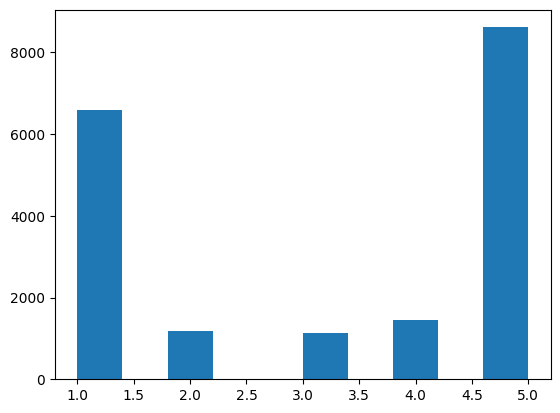

In [16]:
plt.hist(df_zara['score'])
plt.show()

###Detect Language

In [17]:
def detect_language(text):
    try:
        return detect(text)
    except LangDetectException:
        return 'unknown'

In [18]:
df_zara['language'] = df_zara['review'].apply(detect_language)
df_zara[['review', 'language']].head()

,review,language
0,everytime I try to use it the app starts to up...,en
1,smooth online purchase,en
2,Easy app to use,en
3,"great service, thanks",en
4,website a nightmare to make a payment.,en


In [19]:
language_counts = Counter(df_zara['language'])
language_df = pd.DataFrame.from_dict(language_counts, orient='index', columns=['count'])
language_df.index.name = 'language'
language_df = language_df.sort_values(by='count', ascending=False).reset_index()

language_df

,language,count
0,en,13139
1,so,906
2,af,585
3,ro,386
4,sl,359
5,unknown,354
6,ca,324
7,fr,283
8,it,272
9,pl,244


In [20]:
#filter review yang b inggris
df_zara = df_zara[df_zara['language'] == 'en'].copy()

print("Jumlah data setelah filter English:", len(df_zara))
df_zara.head()

Jumlah data setelah filter English: 13139


,id,score,at,review,language
0,1,1,2026-03-30 05:33:51,everytime I try to use it the app starts to up...,en
1,2,5,2026-03-30 05:00:24,smooth online purchase,en
2,3,5,2026-03-29 21:28:12,Easy app to use,en
3,4,5,2026-03-29 10:04:34,"great service, thanks",en
4,5,2,2026-03-29 09:58:21,website a nightmare to make a payment.,en


#Text Pre-Processing

###Sentiment before preprocessing

In [21]:
df_zara['sentiment_polarity'] = df_zara['review'].apply(lambda x: TextBlob(str(x)).sentiment.polarity)
df_zara['sentiment_subjectivity'] = df_zara['review'].apply(lambda x: TextBlob(str(x)).sentiment.subjectivity)

df_zara[['review', 'sentiment_polarity', 'sentiment_subjectivity']].head()

,review,sentiment_polarity,sentiment_subjectivity
0,everytime I try to use it the app starts to up...,-0.316667,0.833333
1,smooth online purchase,0.400000,0.500000
2,Easy app to use,0.433333,0.833333
3,"great service, thanks",0.500000,0.475000
4,website a nightmare to make a payment.,0.000000,0.000000


In [22]:
#sentiment label dari rating
df_zara['sentiment_rating'] = df_zara['score'].apply(
    lambda x: 'Positive' if x > 3 else ('Neutral' if x == 3 else 'Negative'))

df_zara[['score', 'sentiment_rating']].head()

,score,sentiment_rating
0,1,Negative
1,5,Positive
2,5,Positive
3,5,Positive
4,2,Negative


In [23]:
df_zara.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13139 entries, 0 to 19017
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   id                      13139 non-null  int64         
 1   score                   13139 non-null  int64         
 2   at                      13139 non-null  datetime64[ns]
 3   review                  13139 non-null  object        
 4   language                13139 non-null  object        
 5   sentiment_polarity      13139 non-null  float64       
 6   sentiment_subjectivity  13139 non-null  float64       
 7   sentiment_rating        13139 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(2), object(3)
memory usage: 923.8+ KB


In [24]:
print(df_zara[['review', 'sentiment_polarity', 'sentiment_subjectivity', 'sentiment_rating']].head())
print(df_zara['sentiment_rating'].value_counts())

                                              review  sentiment_polarity  \
0  everytime I try to use it the app starts to up...           -0.316667   
1                             smooth online purchase            0.400000   
2                                    Easy app to use            0.433333   
3                              great service, thanks            0.500000   
4             website a nightmare to make a payment.            0.000000   

   sentiment_subjectivity sentiment_rating  
0                0.833333         Negative  
1                0.500000         Positive  
2                0.833333         Positive  
3                0.475000         Positive  
4                0.000000         Negative  
sentiment_rating
Negative    6450
Positive    5748
Neutral      941
Name: count, dtype: int64


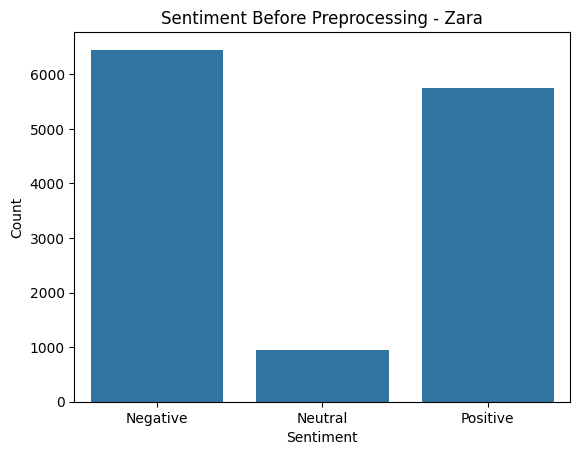

In [25]:
#countplot
sns.countplot(x='sentiment_rating', data=df_zara, order=['Negative', 'Neutral', 'Positive'])
plt.title('Sentiment Before Preprocessing - Zara')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()

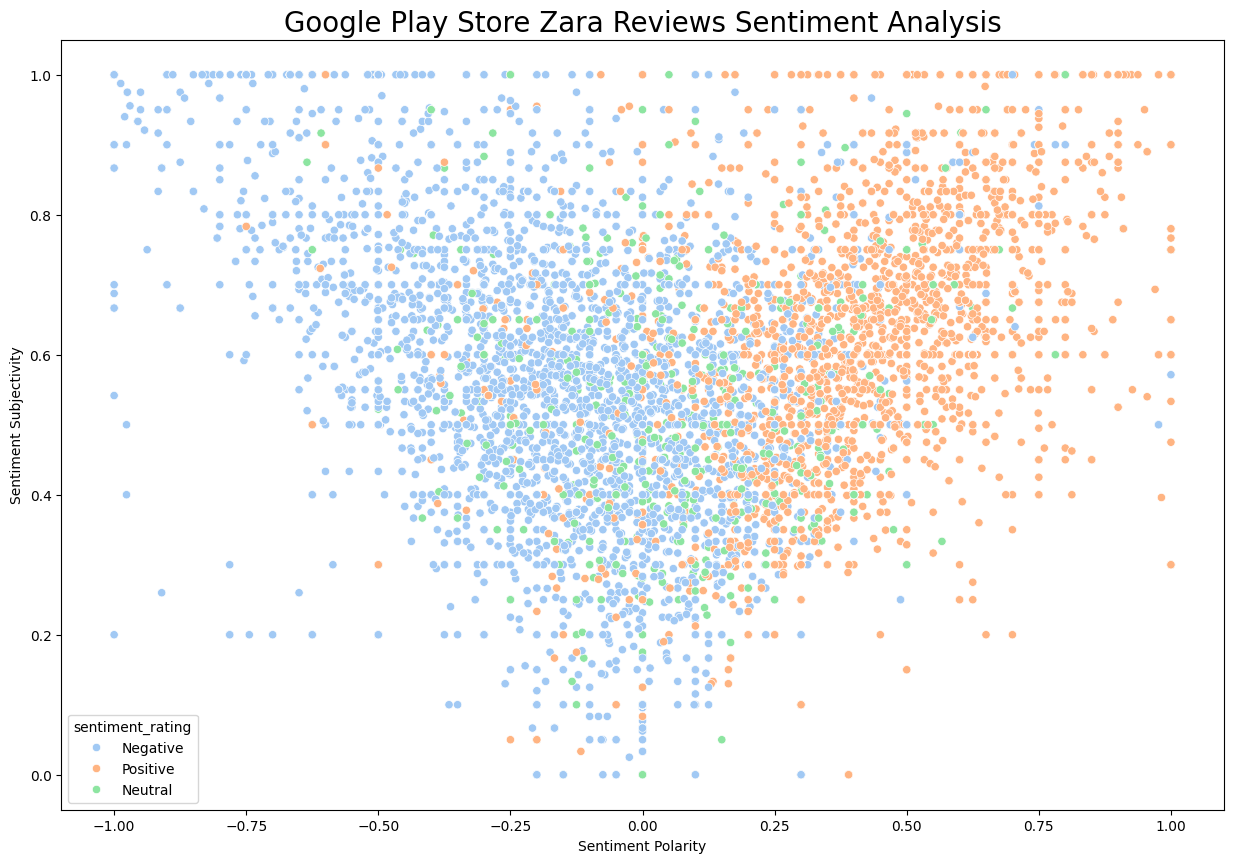

In [26]:
#liat persebaran sentiment
plt.figure(figsize=(15, 10))
sns.scatterplot(
    x=df_zara['sentiment_polarity'],
    y=df_zara['sentiment_subjectivity'],
    hue=df_zara['sentiment_rating'],
    edgecolor='white',
    palette='pastel'
)

plt.title("Google Play Store Zara Reviews Sentiment Analysis", fontsize=20)
plt.xlabel("Sentiment Polarity")
plt.ylabel("Sentiment Subjectivity")
plt.show()

In [27]:
df_zara['review_original'] = df_zara['review']

###Lowercasing

In [28]:
#ubah review jadi string
df_zara['review'] = df_zara['review'].astype(str)

#contoh sebelum lowercasing
print(df_zara['review'].iloc[0])
print(df_zara['review'].iloc[10])
print(df_zara['review'].iloc[20])

everytime I try to use it the app starts to update. can't believe these guys cant make a decent app for once that doesn't need and update. I'll just delete this stupid app and shop elsewhere. peace.
I can't even use the app. What's going on?
not able yo get on account


In [29]:
#buat kolom baru hasil lowercasing
df_zara['review'] = df_zara['review'].apply(lambda x: x.lower())

#contoh habis lowercasing
print(df_zara['review'].iloc[0])
print(df_zara['review'].iloc[10])
print(df_zara['review'].iloc[20])

everytime i try to use it the app starts to update. can't believe these guys cant make a decent app for once that doesn't need and update. i'll just delete this stupid app and shop elsewhere. peace.
i can't even use the app. what's going on?
not able yo get on account


###Remove emoji and special characters

In [30]:
import string
import re

#cek special character
alphabet = string.ascii_letters + string.punctuation
print(df_zara['review'].str.strip(alphabet).astype(bool).any())

True


In [31]:
#ekstrak emoji
extracted_emojis = []

def extract_emojis(text):
    emoji_pattern = re.compile('[\U00010000-\U0010ffff]', flags=re.UNICODE)
    return emoji_pattern.findall(str(text))

for text in df_zara['review']:
    extracted_emojis.append(str(extract_emojis(text)))

print(extracted_emojis[:20])

['[]', '[]', '[]', '[]', '[]', '[]', "['🤩']", '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]']


In [32]:
def cleaning_text(text):
    text = str(text)
    text = re.sub(r'[\n\r\t]', ' ', text) #hapus newline/tab
    text = text.replace('\\n', ' ').replace('\\t', ' ') #hapus karakter escape
    text = text.encode('ascii', 'replace').decode('ascii') #hapus non-ASCII/emoji
    text = re.sub(r'http\S+|www\S+|https\S+', '', text) #hapus URL
    text = re.sub(r'\s+', ' ', text).strip() #hapus spasi berlebih
    text = text.translate(str.maketrans('', '', string.punctuation)) #hapus tanda baca
    return text

In [33]:
df_zara['review'] = df_zara['review'].apply(cleaning_text)
df_zara[['review_original', 'review']].head()

,review_original,review
0,everytime I try to use it the app starts to up...,everytime i try to use it the app starts to up...
1,smooth online purchase,smooth online purchase
2,Easy app to use,easy app to use
3,"great service, thanks",great service thanks
4,website a nightmare to make a payment.,website a nightmare to make a payment


##Stopwords Removal

###Before stopwords removal

In [34]:
from collections import Counter

def freq_words(x, terms=30):
    all_words = ' '.join([text for text in x])
    all_words = all_words.split()

    # Count word frequency using Counter (faster than FreqDist)
    word_counts = Counter(all_words)
    words_df = pd.DataFrame(word_counts.items(), columns=['word', 'count'])

    # Select top 'terms' most frequent words
    d = words_df.nlargest(columns="count", n=terms)

    plt.figure(figsize=(20,5))
    ax = sns.barplot(data=d, x="word", y="count", palette="rainbow")
    ax.set(ylabel='Count')
    plt.show()

/tmp/ipykernel_54815/532702286.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=d, x="word", y="count", palette="rainbow")


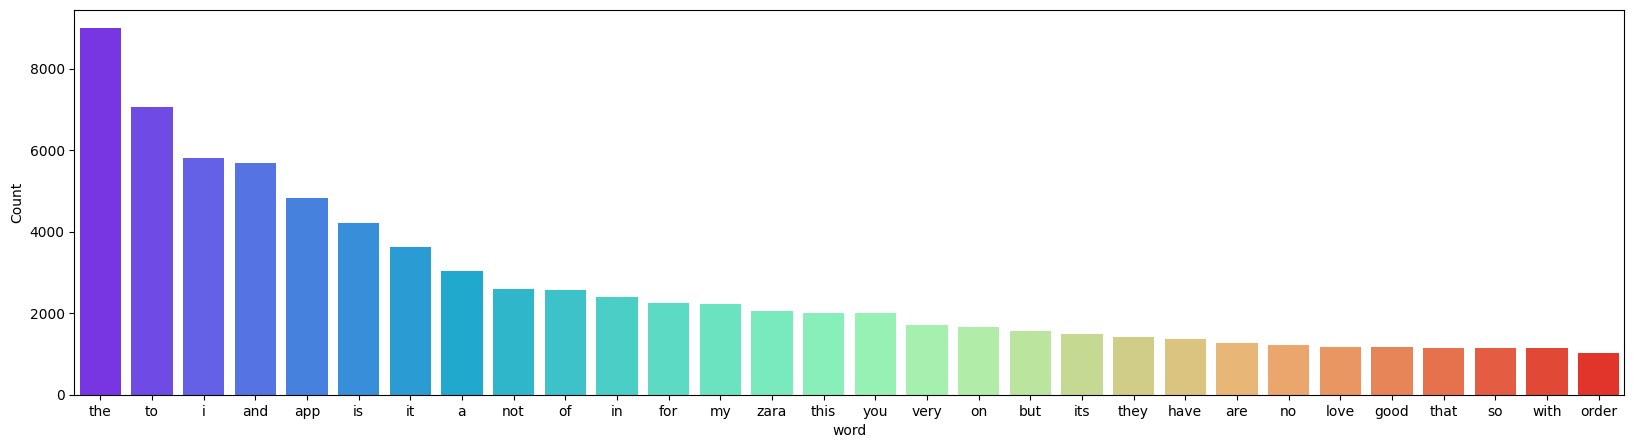

In [35]:
freq_words(df_zara['review'])

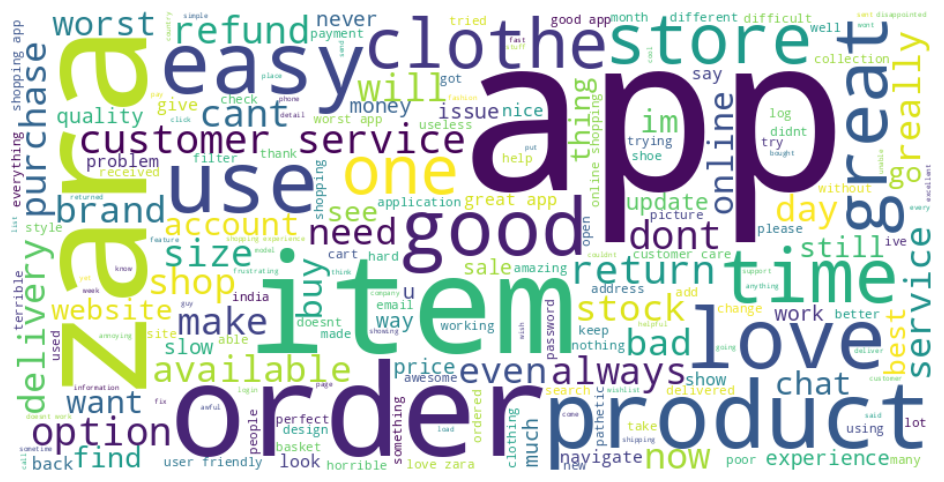

In [36]:
from wordcloud import WordCloud

# Join all of the words in the 'content' in one string
all_words_before = ' '.join(df_zara['review'])

# WordCloud before removing stopwords
wordcloud_before = WordCloud(width=800, height=400, background_color='white').generate(all_words_before)
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud_before, interpolation='bilinear')
plt.axis('off')
plt.show()

###Expand Contractions

In [37]:
!pip install spacy
!pip install contractions
import spacy
import contractions

In [38]:
def expand_contractions(text):
    return contractions.fix(text)  # "can't" → "cannot"

In [39]:
df_zara['review'] = df_zara['review'].apply(expand_contractions)
df_zara['review'].head()

,review
0,everytime i try to use it the app starts to up...
1,smooth online purchase
2,easy app to use
3,great service thanks
4,website a nightmare to make a payment


###Tokenization

In [40]:
from nltk.tokenize import word_tokenize

# Download the 'punkt_tab' resource if it's not already downloaded
nltk.download('punkt_tab')

# Tokenize the 'cleaned_text' column
df_zara['token'] = df_zara['review'].apply(word_tokenize)

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [41]:
# Display results
print(df_zara[['review', 'token']])

                                                  review  \
0      everytime i try to use it the app starts to up...   
1                                 smooth online purchase   
2                                        easy app to use   
3                                   great service thanks   
4                  website a nightmare to make a payment   
...                                                  ...   
19012                                   threat was found   
19013  the app is very well organized and easy to use...   
19014                                          brilliant   
19016  easiest buying process ever  never miss the op...   
19017  anytime i share something through the app via ...   

                                                   token  
0      [everytime, i, try, to, use, it, the, app, sta...  
1                             [smooth, online, purchase]  
2                                   [easy, app, to, use]  
3                               [great, ser

In [42]:
df_zara.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13139 entries, 0 to 19017
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   id                      13139 non-null  int64         
 1   score                   13139 non-null  int64         
 2   at                      13139 non-null  datetime64[ns]
 3   review                  13139 non-null  object        
 4   language                13139 non-null  object        
 5   sentiment_polarity      13139 non-null  float64       
 6   sentiment_subjectivity  13139 non-null  float64       
 7   sentiment_rating        13139 non-null  object        
 8   review_original         13139 non-null  object        
 9   token                   13139 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(2), object(5)
memory usage: 1.1+ MB


###Removing Stopwords

In [43]:
nltk.download('stopwords')
from nltk.corpus import stopwords

#Get English stopwords
english_stopwords = stopwords.words('english')

# HAPUS negation dari stopwords
negation_words = ['not', 'no', 'nor', 'never']
english_stopwords = [word for word in english_stopwords if word not in negation_words]

# Tambahan custom
english_stopwords.extend(['app'])

#Apply the extended stopwords to your DataFrame
df_zara["token_after_sr"] = df_zara["token"].apply(lambda tokens: [word for word in tokens if word not in english_stopwords and word.isalpha()])
#Gabungkan token menjadi teks yang bersih dalam kolom cleaned_content
df_zara["cleaned_content"] = df_zara["token_after_sr"].apply(lambda tokens: ' '.join(tokens))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [44]:
df_zara.head()

,id,score,at,review,language,sentiment_polarity,sentiment_subjectivity,sentiment_rating,review_original,token,token_after_sr,cleaned_content
0,1,1,2026-03-30 05:33:51,everytime i try to use it the app starts to up...,en,-0.316667,0.833333,Negative,everytime I try to use it the app starts to up...,"[everytime, i, try, to, use, it, the, app, sta...","[everytime, try, use, starts, update, not, bel...",everytime try use starts update not believe gu...
1,2,5,2026-03-30 05:00:24,smooth online purchase,en,0.400000,0.500000,Positive,smooth online purchase,"[smooth, online, purchase]","[smooth, online, purchase]",smooth online purchase
2,3,5,2026-03-29 21:28:12,easy app to use,en,0.433333,0.833333,Positive,Easy app to use,"[easy, app, to, use]","[easy, use]",easy use
3,4,5,2026-03-29 10:04:34,great service thanks,en,0.500000,0.475000,Positive,"great service, thanks","[great, service, thanks]","[great, service, thanks]",great service thanks
4,5,2,2026-03-29 09:58:21,website a nightmare to make a payment,en,0.000000,0.000000,Negative,website a nightmare to make a payment.,"[website, a, nightmare, to, make, a, payment]","[website, nightmare, make, payment]",website nightmare make payment


/tmp/ipykernel_54815/532702286.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=d, x="word", y="count", palette="rainbow")


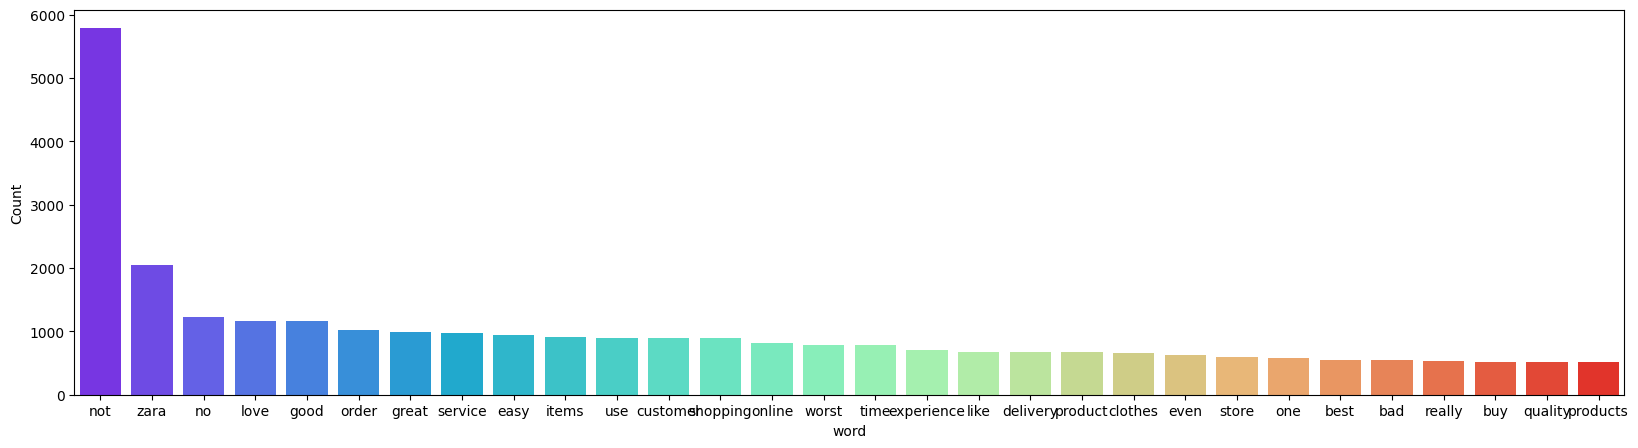

In [45]:
# Frekuensi kata setelah pembersihan stopwords
freq_words(df_zara['cleaned_content'])

##Lemmatization

In [46]:
from nltk.stem import WordNetLemmatizer

#download resource
nltk.download('wordnet')
nltk.download('omw-1.4')

#Inisialisasi lemmatizer
lemmatizer = WordNetLemmatizer()

#Fungsi lemmatization
def lemmatize_tokens(tokens):
    return [lemmatizer.lemmatize(word) for word in tokens]

#Terapkan ke kolom token
df_zara["token_after_lemma"] = df_zara["token_after_sr"].apply(lemmatize_tokens)

#Gabungkan jadi kalimat
df_zara["cleaned_content"] = df_zara["token_after_lemma"].apply(lambda tokens: ' '.join(tokens))
df_zara.head()

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


,id,score,at,review,language,sentiment_polarity,sentiment_subjectivity,sentiment_rating,review_original,token,token_after_sr,cleaned_content,token_after_lemma
0,1,1,2026-03-30 05:33:51,everytime i try to use it the app starts to up...,en,-0.316667,0.833333,Negative,everytime I try to use it the app starts to up...,"[everytime, i, try, to, use, it, the, app, sta...","[everytime, try, use, starts, update, not, bel...",everytime try use start update not believe guy...,"[everytime, try, use, start, update, not, beli..."
1,2,5,2026-03-30 05:00:24,smooth online purchase,en,0.400000,0.500000,Positive,smooth online purchase,"[smooth, online, purchase]","[smooth, online, purchase]",smooth online purchase,"[smooth, online, purchase]"
2,3,5,2026-03-29 21:28:12,easy app to use,en,0.433333,0.833333,Positive,Easy app to use,"[easy, app, to, use]","[easy, use]",easy use,"[easy, use]"
3,4,5,2026-03-29 10:04:34,great service thanks,en,0.500000,0.475000,Positive,"great service, thanks","[great, service, thanks]","[great, service, thanks]",great service thanks,"[great, service, thanks]"
4,5,2,2026-03-29 09:58:21,website a nightmare to make a payment,en,0.000000,0.000000,Negative,website a nightmare to make a payment.,"[website, a, nightmare, to, make, a, payment]","[website, nightmare, make, payment]",website nightmare make payment,"[website, nightmare, make, payment]"


In [47]:
print(df_zara['token_after_sr'][0])
print(df_zara['token_after_lemma'][0])

['everytime', 'try', 'use', 'starts', 'update', 'not', 'believe', 'guys', 'not', 'make', 'decent', 'not', 'need', 'update', 'ill', 'delete', 'stupid', 'shop', 'elsewhere', 'peace']
['everytime', 'try', 'use', 'start', 'update', 'not', 'believe', 'guy', 'not', 'make', 'decent', 'not', 'need', 'update', 'ill', 'delete', 'stupid', 'shop', 'elsewhere', 'peace']


##Stemming

In [48]:
from nltk.stem import PorterStemmer

nltk.download('punkt')

stemmer = PorterStemmer()

def stem_text(tokens):
    return [stemmer.stem(token) for token in tokens]

# Terapkan stemming ke hasil lemma
df_zara['token_after_stem'] = df_zara['token_after_lemma'].apply(stem_text)

# Lihat perbandingan
df_zara[['token_after_lemma', 'token_after_stem']].head()

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


,token_after_lemma,token_after_stem
0,"[everytime, try, use, start, update, not, beli...","[everytim, tri, use, start, updat, not, believ..."
1,"[smooth, online, purchase]","[smooth, onlin, purchas]"
2,"[easy, use]","[easi, use]"
3,"[great, service, thanks]","[great, servic, thank]"
4,"[website, nightmare, make, payment]","[websit, nightmar, make, payment]"


In [49]:
print(df_zara['token_after_lemma'][0])
print(df_zara['token_after_stem'][0])

['everytime', 'try', 'use', 'start', 'update', 'not', 'believe', 'guy', 'not', 'make', 'decent', 'not', 'need', 'update', 'ill', 'delete', 'stupid', 'shop', 'elsewhere', 'peace']
['everytim', 'tri', 'use', 'start', 'updat', 'not', 'believ', 'guy', 'not', 'make', 'decent', 'not', 'need', 'updat', 'ill', 'delet', 'stupid', 'shop', 'elsewher', 'peac']


In [50]:
# Gabungkan kembali token setelah lemmatization menjadi satu string
df_zara["cleaned_content"] = df_zara["token_after_lemma"].apply(lambda tokens: ' '.join(tokens))

# Tampilkan 5 baris pertama DataFrame untuk verifikasi
df_zara.head()

,id,score,at,review,language,sentiment_polarity,sentiment_subjectivity,sentiment_rating,review_original,token,token_after_sr,cleaned_content,token_after_lemma,token_after_stem
0,1,1,2026-03-30 05:33:51,everytime i try to use it the app starts to up...,en,-0.316667,0.833333,Negative,everytime I try to use it the app starts to up...,"[everytime, i, try, to, use, it, the, app, sta...","[everytime, try, use, starts, update, not, bel...",everytime try use start update not believe guy...,"[everytime, try, use, start, update, not, beli...","[everytim, tri, use, start, updat, not, believ..."
1,2,5,2026-03-30 05:00:24,smooth online purchase,en,0.400000,0.500000,Positive,smooth online purchase,"[smooth, online, purchase]","[smooth, online, purchase]",smooth online purchase,"[smooth, online, purchase]","[smooth, onlin, purchas]"
2,3,5,2026-03-29 21:28:12,easy app to use,en,0.433333,0.833333,Positive,Easy app to use,"[easy, app, to, use]","[easy, use]",easy use,"[easy, use]","[easi, use]"
3,4,5,2026-03-29 10:04:34,great service thanks,en,0.500000,0.475000,Positive,"great service, thanks","[great, service, thanks]","[great, service, thanks]",great service thanks,"[great, service, thanks]","[great, servic, thank]"
4,5,2,2026-03-29 09:58:21,website a nightmare to make a payment,en,0.000000,0.000000,Negative,website a nightmare to make a payment.,"[website, a, nightmare, to, make, a, payment]","[website, nightmare, make, payment]",website nightmare make payment,"[website, nightmare, make, payment]","[websit, nightmar, make, payment]"


#Sentiment Analysis after Text Perprocessing

In [51]:
df_zara2 = df_zara.copy()

df_zara2 = df_zara2.drop(columns=['sentiment_polarity', 'sentiment_subjectivity'])
df_zara2.head()

,id,score,at,review,language,sentiment_rating,review_original,token,token_after_sr,cleaned_content,token_after_lemma,token_after_stem
0,1,1,2026-03-30 05:33:51,everytime i try to use it the app starts to up...,en,Negative,everytime I try to use it the app starts to up...,"[everytime, i, try, to, use, it, the, app, sta...","[everytime, try, use, starts, update, not, bel...",everytime try use start update not believe guy...,"[everytime, try, use, start, update, not, beli...","[everytim, tri, use, start, updat, not, believ..."
1,2,5,2026-03-30 05:00:24,smooth online purchase,en,Positive,smooth online purchase,"[smooth, online, purchase]","[smooth, online, purchase]",smooth online purchase,"[smooth, online, purchase]","[smooth, onlin, purchas]"
2,3,5,2026-03-29 21:28:12,easy app to use,en,Positive,Easy app to use,"[easy, app, to, use]","[easy, use]",easy use,"[easy, use]","[easi, use]"
3,4,5,2026-03-29 10:04:34,great service thanks,en,Positive,"great service, thanks","[great, service, thanks]","[great, service, thanks]",great service thanks,"[great, service, thanks]","[great, servic, thank]"
4,5,2,2026-03-29 09:58:21,website a nightmare to make a payment,en,Negative,website a nightmare to make a payment.,"[website, a, nightmare, to, make, a, payment]","[website, nightmare, make, payment]",website nightmare make payment,"[website, nightmare, make, payment]","[websit, nightmar, make, payment]"


In [52]:
df_zara2['cleaned_content'] = df_zara2['cleaned_content'].fillna('')

df_zara2['sentiment_polarity'] = df_zara2['cleaned_content'].apply(lambda x: TextBlob(x).polarity)
df_zara2['sentiment_subjective'] = df_zara2['cleaned_content'].apply(lambda x: TextBlob(x).subjectivity)


# Display the results
df_zara2

,id,score,at,review,language,sentiment_rating,review_original,token,token_after_sr,cleaned_content,token_after_lemma,token_after_stem,sentiment_polarity,sentiment_subjective
0,1,1,2026-03-30 05:33:51,everytime i try to use it the app starts to up...,en,Negative,everytime I try to use it the app starts to up...,"[everytime, i, try, to, use, it, the, app, sta...","[everytime, try, use, starts, update, not, bel...",everytime try use start update not believe guy...,"[everytime, try, use, start, update, not, beli...","[everytim, tri, use, start, updat, not, believ...",-0.377778,0.888889
1,2,5,2026-03-30 05:00:24,smooth online purchase,en,Positive,smooth online purchase,"[smooth, online, purchase]","[smooth, online, purchase]",smooth online purchase,"[smooth, online, purchase]","[smooth, onlin, purchas]",0.400000,0.500000
2,3,5,2026-03-29 21:28:12,easy app to use,en,Positive,Easy app to use,"[easy, app, to, use]","[easy, use]",easy use,"[easy, use]","[easi, use]",0.433333,0.833333
3,4,5,2026-03-29 10:04:34,great service thanks,en,Positive,"great service, thanks","[great, service, thanks]","[great, service, thanks]",great service thanks,"[great, service, thanks]","[great, servic, thank]",0.500000,0.475000
4,5,2,2026-03-29 09:58:21,website a nightmare to make a payment,en,Negative,website a nightmare to make a payment.,"[website, a, nightmare, to, make, a, payment]","[website, nightmare, make, payment]",website nightmare make payment,"[website, nightmare, make, payment]","[websit, nightmar, make, payment]",0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19012,19013,1,2012-11-18 04:23:17,threat was found,en,Negative,Threat was found.,"[threat, was, found]","[threat, found]",threat found,"[threat, found]","[threat, found]",0.000000,0.000000
19013,19014,4,2012-11-17 07:19:17,the app is very well organized and easy to use...,en,Positive,The app is very well organized and easy to use...,"[the, app, is, very, well, organized, and, eas...","[well, organized, easy, use, definetely, stars]",well organized easy use definetely star,"[well, organized, easy, use, definetely, star]","[well, organ, easi, use, definet, star]",0.433333,0.833333
19014,19015,5,2012-11-11 15:58:35,brilliant,en,Positive,Brilliant!,[brilliant],[brilliant],brilliant,[brilliant],[brilliant],0.900000,1.000000
19016,19017,5,2012-11-07 07:10:55,easiest buying process ever never miss the op...,en,Positive,Easiest buying process ever . Never miss the o...,"[easiest, buying, process, ever, never, miss, ...","[easiest, buying, process, ever, never, miss, ...",easiest buying process ever never miss opportu...,"[easiest, buying, process, ever, never, miss, ...","[easiest, buy, process, ever, never, miss, opp...",0.600000,0.900000


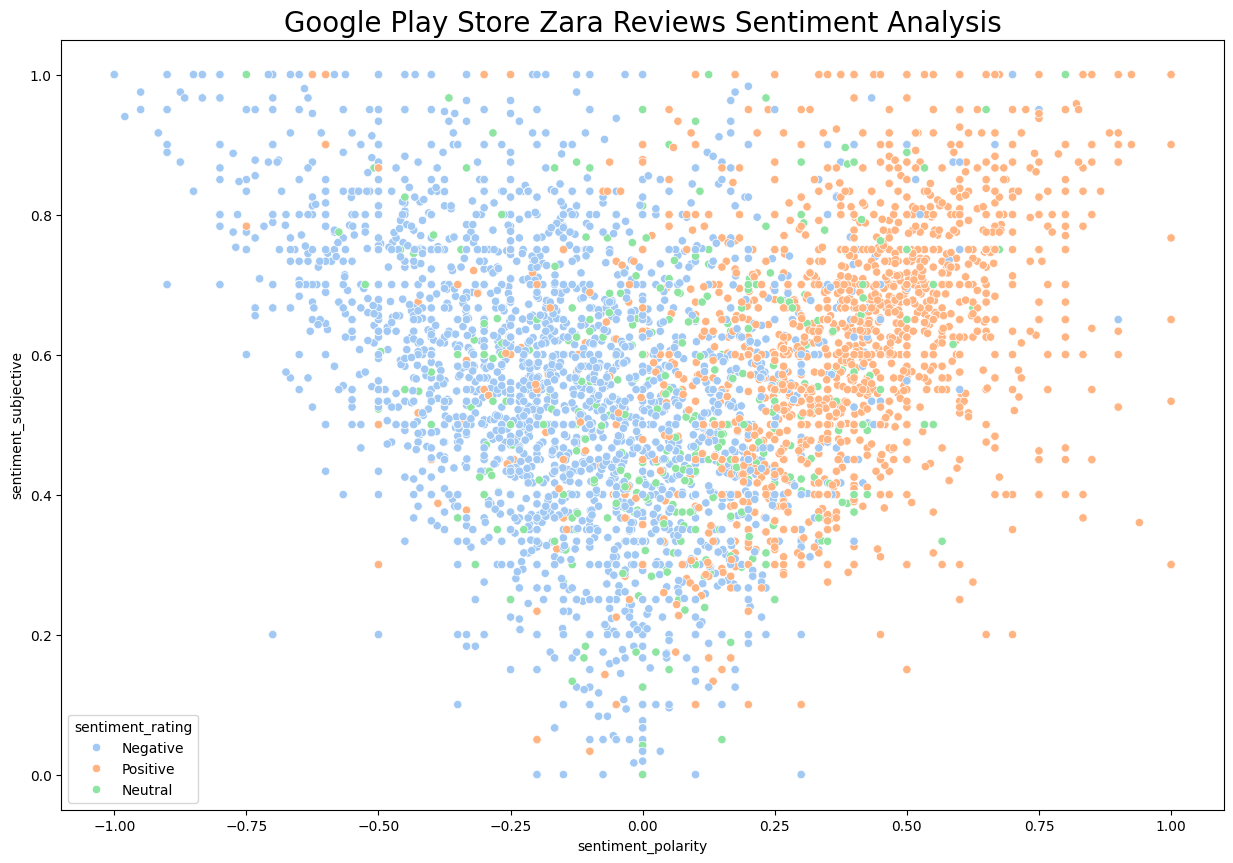

In [53]:
plt.figure(figsize=(15, 10))
# Specify x and y using the 'x' and 'y' parameters within sns.scatterplot
sns.scatterplot(x=df_zara2['sentiment_polarity'], y=df_zara2['sentiment_subjective'],
                hue=df_zara2['sentiment_rating'], edgecolor='white', palette="pastel")
plt.title("Google Play Store Zara Reviews Sentiment Analysis", fontsize=20)
plt.show()

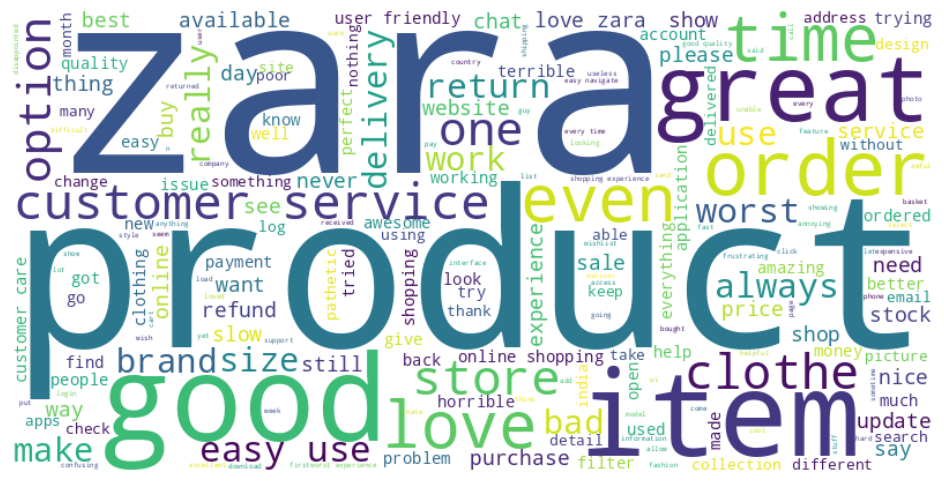

In [54]:
# Join all of the words in the 'review' in one string
all_words_before = ' '.join(df_zara2['cleaned_content'])

# WordCloud before removing stopwords
wordcloud_before = WordCloud(width=800, height=400, background_color='white').generate(all_words_before)
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud_before, interpolation='bilinear')
plt.axis('off')
plt.show()

#Extract to New CSV

In [55]:
df_zara2.to_csv('/content/drive/MyDrive/Tugas-1A-PBA/text_preprocessed_review_zara.csv', index=False)

#Exploratory Data Analysis

##Distribusi Skor

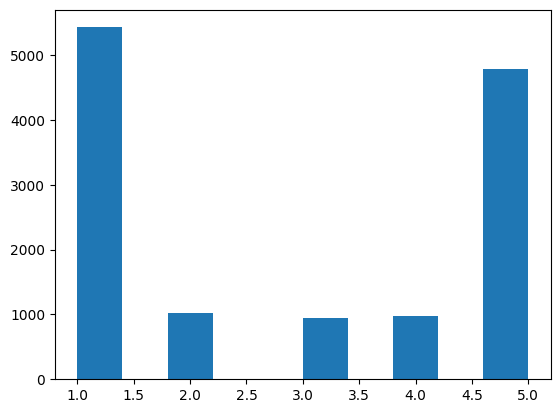

In [56]:
plt.hist(df_zara2['score'])
plt.show()

##Jumlah review per tahun

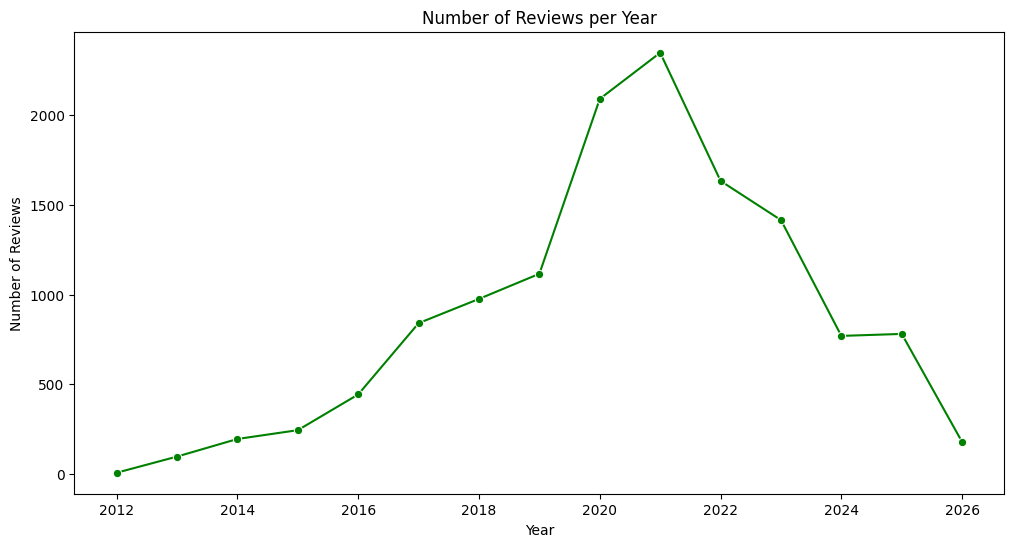

In [57]:
df_zara2['at'] = pd.to_datetime(df_zara2['at'])
df_zara2['year'] = df_zara2['at'].dt.year
year_counts = df_zara2['year'].value_counts().sort_index()
plt.figure(figsize=(12, 6))
sns.lineplot(x=year_counts.index, y=year_counts.values, marker='o', color='green')
plt.title('Number of Reviews per Year')
plt.xlabel('Year')
plt.ylabel('Number of Reviews')
plt.show()

##Jumlah review tiap bulan di setiap tahun

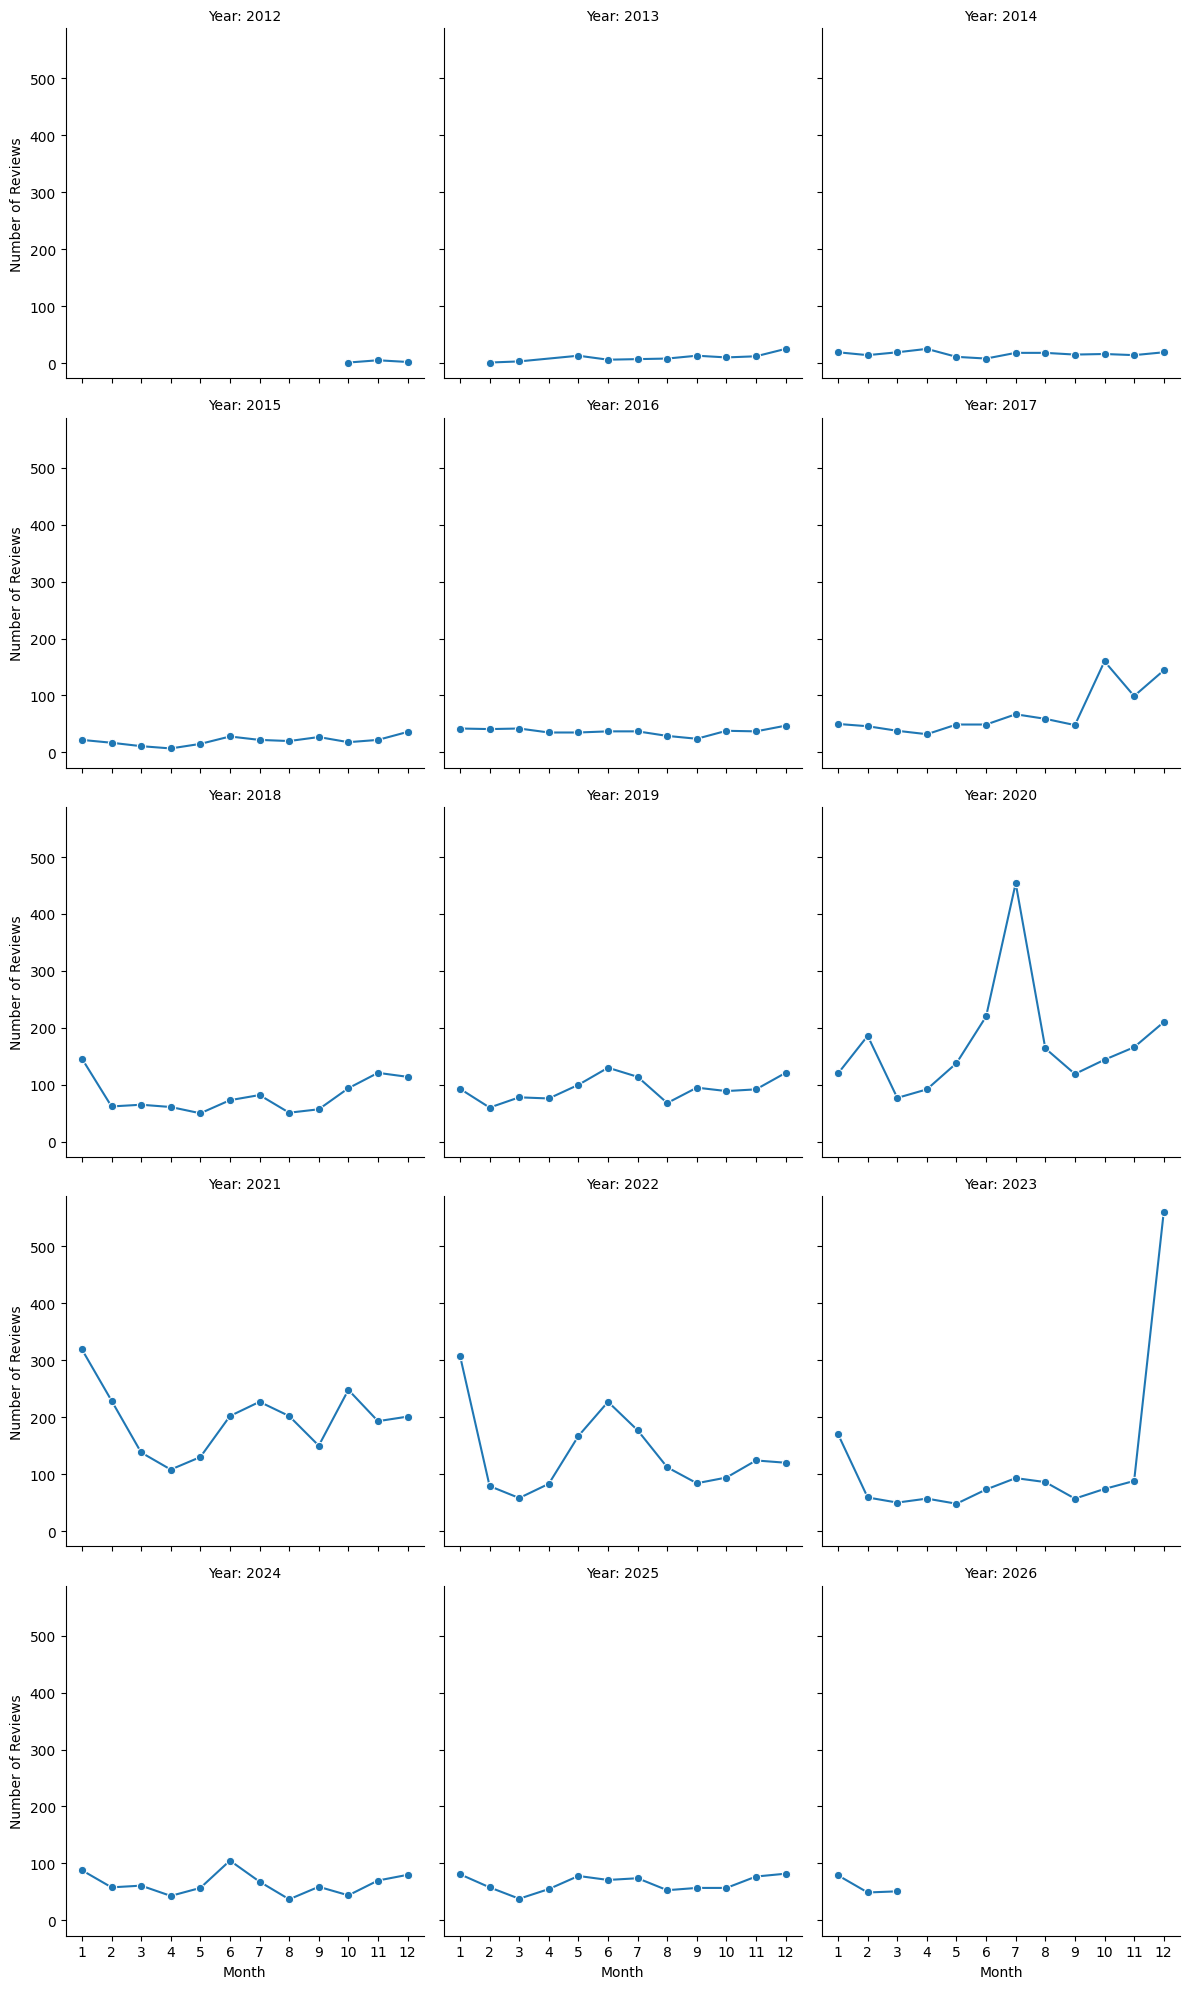

In [58]:
# Ekstrak tahun dan bulan
df_zara2['year'] = df_zara2['at'].dt.year
df_zara2['month'] = df_zara2['at'].dt.month

# Group by year and month and count reviews
reviews_per_month = df_zara2.groupby(['year', 'month'])['id'].count().reset_index()

# Buat grid plot dengan FacetGrid
g = sns.FacetGrid(reviews_per_month, col='year', col_wrap=3, height=4, sharey=True)
g.map(sns.lineplot, 'month', 'id', marker='o')

# Tambahkan judul & label
g.set_axis_labels("Month", "Number of Reviews")
g.set_titles("Year: {col_name}")
plt.xticks(range(1, 13))  # Pastikan semua bulan muncul

plt.show()

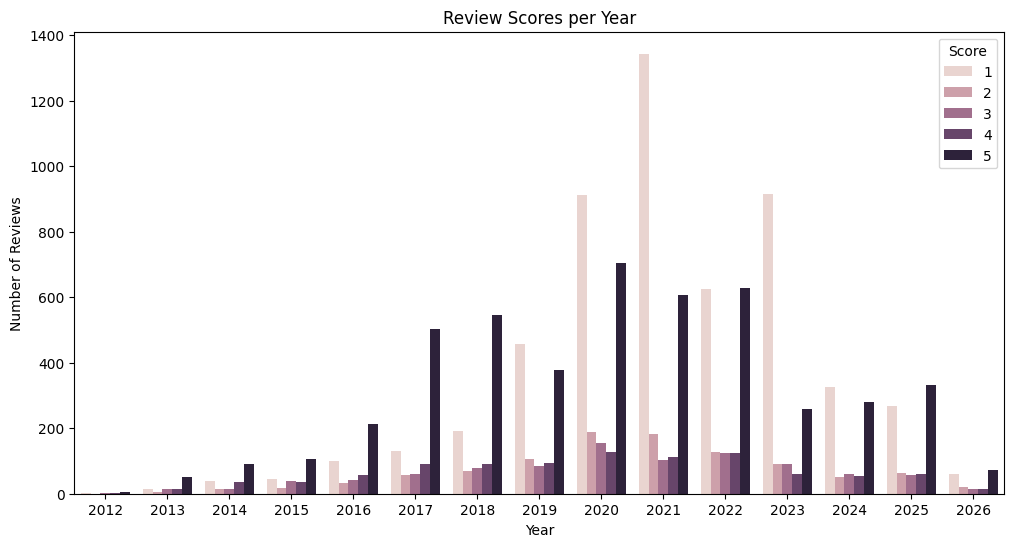

score,1,2,3,4,5
year,,,,,
2012,1,0,1,2,4
2013,14,4,14,14,52
2014,38,15,15,36,92
2015,44,17,40,37,107
2016,99,32,43,57,213
2017,131,56,59,92,503
2018,192,68,79,90,547
2019,456,105,84,93,378
2020,913,189,156,127,705


In [59]:
# Convert 'at' column to datetime objects
df_zara['at'] = pd.to_datetime(df_zara['at'])

# Create a 'year' column from the 'at' column
df_zara['year'] = df_zara['at'].dt.year

# Group data by year and score, then count occurrences
score_per_year = df_zara.groupby(['year', 'score'])['id'].count().reset_index()

# Create the bar chart
plt.figure(figsize=(12, 6))
sns.barplot(x='year', y='id', hue='score', data=score_per_year)
plt.xlabel('Year')
plt.ylabel('Number of Reviews')
plt.title('Review Scores per Year')
plt.legend(title='Score')
plt.show()

# Assuming df_gfrev is your DataFrame and it has 'year' and 'score' columns
score_per_year = df_zara.groupby('year')['score'].value_counts().unstack(fill_value=0)
score_per_year

##Wordcloud

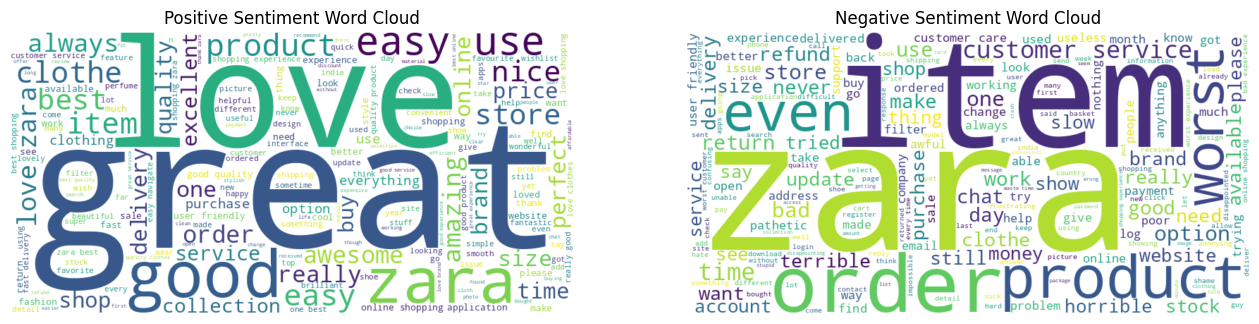

In [60]:
# Separate positive and negative reviews
positive_reviews = df_zara[df_zara['sentiment_rating'] == 'Positive']['cleaned_content']
negative_reviews = df_zara[df_zara['sentiment_rating'] == 'Negative']['cleaned_content']

# Create word clouds
positive_wordcloud = WordCloud(width=800, height=400, background_color='white').generate(' '.join(positive_reviews))
negative_wordcloud = WordCloud(width=800, height=400, background_color='white').generate(' '.join(negative_reviews))

# Display the word clouds
plt.figure(figsize=(16, 8))

plt.subplot(1, 2, 1)
plt.imshow(positive_wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Positive Sentiment Word Cloud")

plt.subplot(1, 2, 2)
plt.imshow(negative_wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Negative Sentiment Word Cloud")

plt.show()

In [62]:
from textblob import TextBlob

df_check = df_neg.copy()

df_check['before'] = df_check['review'].apply(lambda x: TextBlob(str(x)).sentiment.polarity)
df_check['after'] = df_check['cleaned_content'].apply(lambda x: TextBlob(str(x)).sentiment.polarity)

df_check[['review', 'cleaned_content', 'before', 'after']].head(10)

,review,cleaned_content,before,after
0,everytime i try to use it the app starts to up...,everytime try use start update not believe guy...,-0.377778,-0.377778
5,the app is hard to navigate for some time now ...,hard navigate time newest update not use black...,-0.186667,-0.241667
7,app is not working deleted my old account had ...,not working deleted old account create new acc...,0.118182,0.118182
13,i cannot even use the app what is going on,not even use going,0.000000,0.000000
14,the app does not loads pictures of any product...,not load picture product time restart make wor...,0.250000,0.000000
15,overall the app is ok but the back navigation ...,overall ok back navigation gesture lead upward...,-0.056000,-0.020000
20,new version is very bad you cannot see picture...,new version bad not see picture keep freezing ...,-0.386818,-0.281818
24,browsing items on the app is pathetic if we cl...,browsing item pathetic click back go list item...,-0.041323,-0.035714
25,not able yo get on account,not able yo get account,-0.250000,-0.250000
26,why not filter product on the basis of bust si...,not filter product basis bust size hip size li...,-0.250000,-0.250000


In [63]:
df_changed = df_check[df_check['before'] != df_check['after']]

df_changed[['review', 'cleaned_content', 'before', 'after']].head(10)

,review,cleaned_content,before,after
5,the app is hard to navigate for some time now ...,hard navigate time newest update not use black...,-0.186667,-0.241667
14,the app does not loads pictures of any product...,not load picture product time restart make wor...,0.250000,0.000000
15,overall the app is ok but the back navigation ...,overall ok back navigation gesture lead upward...,-0.056000,-0.020000
20,new version is very bad you cannot see picture...,new version bad not see picture keep freezing ...,-0.386818,-0.281818
24,browsing items on the app is pathetic if we cl...,browsing item pathetic click back go list item...,-0.041323,-0.035714
35,zara website is not user friendly compared to ...,zara website not user friendly compared fashio...,0.125000,0.375000
47,this was seriously the only decent online clot...,seriously decent online clothing store japan r...,-0.054630,-0.109722
60,the barcode scanner keeps disappearing from th...,barcode scanner keep disappearing even reinsta...,-0.520000,-0.400000
68,bad app and overall customer experience took a...,bad overall customer experience took month rec...,-0.142551,-0.171061
79,app is always closing down its not even a rec...,always closing not even recent thing always ha...,-0.288889,-0.333333


In [64]:
df_zara[df_zara['review_original'].str.contains("can't", na=False)][['review_original', 'review']].head()

,review_original,review
0,everytime I try to use it the app starts to up...,everytime i try to use it the app starts to up...
5,"The app is hard to navigate for some time now,...",the app is hard to navigate for some time now ...
13,I can't even use the app. What's going on?,i cannot even use the app what is going on
15,overall the app is ok. but the back navigation...,overall the app is ok but the back navigation ...
20,new version is very bad. you can't see picture...,new version is very bad you cannot see picture...
